# Sepsis Prediction — Model Development

This notebook develops and evaluates machine-learning models for sepsis prediction using the processed datasets generated during the preprocessing stage.

The processed datasets contain five clinical domain scores along with temporal, demographic, and ICU-related features.

The main objectives are:

- Load the processed training, validation, and test datasets
- Prepare model features and target variables
- Handle categorical variables appropriately
- Train baseline and machine-learning models
- Account for severe class imbalance
- Evaluate model performance using classification metrics
- Compare model behaviour across validation and test data
- Analyze feature importance and model interpretability

___
___

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb

In [3]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
val_df = pd.read_csv("../data/processed/val_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1086991, 12)
Validation shape: (155226, 12)
Test shape: (309993, 12)


In [4]:
final_features = [
    "Hemodynamic",
    "Respiratory",
    "Renal_Metabolic",
    "Inflammatory_Hematological",
    "Hepatic_Coagulation",
    "Hour",
    "ICULOS",
    "HospAdmTime",
    "Gender",
    "ICU_Unit"
]

target = "SepsisLabel"

In [5]:
X_train = train_df[final_features].copy()
y_train = train_df[target].copy()

X_val = val_df[final_features].copy()
y_val = val_df[target].copy()

X_test = test_df[final_features].copy()
y_test = test_df[target].copy()

In [6]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

print("\nTarget distribution:")
print(y_train.value_counts())

print("\nTarget percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

X_train: (1086991, 10)
y_train: (1086991,)
X_val: (155226, 10)
y_val: (155226,)
X_test: (309993, 10)
y_test: (309993,)

Features:
['Hemodynamic', 'Respiratory', 'Renal_Metabolic', 'Inflammatory_Hematological', 'Hepatic_Coagulation', 'Hour', 'ICULOS', 'HospAdmTime', 'Gender', 'ICU_Unit']

Target distribution:
SepsisLabel
0    1067723
1      19268
Name: count, dtype: int64

Target percentages:
SepsisLabel
0    98.23
1     1.77
Name: proportion, dtype: float64


In [7]:
print("Data types:")
print(X_train.dtypes)

print("\nMissing values:")
print(X_train.isna().sum())

print("\nMissing percentages:")
print((X_train.isna().mean() * 100).round(2))

Data types:
Hemodynamic                   float64
Respiratory                   float64
Renal_Metabolic               float64
Inflammatory_Hematological    float64
Hepatic_Coagulation           float64
Hour                            int64
ICULOS                          int64
HospAdmTime                   float64
Gender                          int64
ICU_Unit                      float64
dtype: object

Missing values:
Hemodynamic                    24485
Respiratory                    24365
Renal_Metabolic               132386
Inflammatory_Hematological    206843
Hepatic_Coagulation           398226
Hour                               0
ICULOS                             0
HospAdmTime                        0
Gender                             0
ICU_Unit                           0
dtype: int64

Missing percentages:
Hemodynamic                    2.25
Respiratory                    2.24
Renal_Metabolic               12.18
Inflammatory_Hematological    19.03
Hepatic_Coagulation         

In [8]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("Scale pos weight:", scale_pos_weight)

Negative samples: 1067723
Positive samples: 19268
Scale pos weight: 55.41431388831223


___
___

## Creating xgboost

In [9]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [10]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.08682	validation_1-aucpr:0.07833
[50]	validation_0-aucpr:0.12426	validation_1-aucpr:0.09113
[100]	validation_0-aucpr:0.15100	validation_1-aucpr:0.08706
[150]	validation_0-aucpr:0.17938	validation_1-aucpr:0.08683
[200]	validation_0-aucpr:0.20737	validation_1-aucpr:0.08506
[250]	validation_0-aucpr:0.23245	validation_1-aucpr:0.08441
[299]	validation_0-aucpr:0.25215	validation_1-aucpr:0.08207


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
results = model.evals_result()

val_aucpr = results["validation_1"]["aucpr"]

best_iteration = np.argmax(val_aucpr)
best_val_aucpr = val_aucpr[best_iteration]

print("Best iteration:", best_iteration)
print("Best validation PR-AUC:", best_val_aucpr)

Best iteration: 47
Best validation PR-AUC: 0.09135821942082577


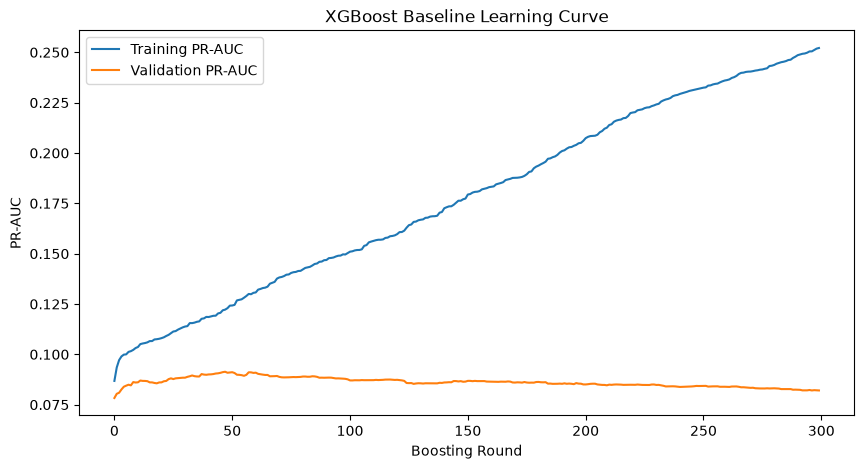

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    results["validation_0"]["aucpr"],
    label="Training PR-AUC"
)

plt.plot(
    results["validation_1"]["aucpr"],
    label="Validation PR-AUC"
)

plt.xlabel("Boosting Round")
plt.ylabel("PR-AUC")
plt.title("XGBoost Baseline Learning Curve")
plt.legend()
plt.show()

In [13]:
# Generate validation probabilities using the best iteration
val_prob = model.predict_proba(
    X_val,
    iteration_range=(0, best_iteration + 1)
)[:, 1]

# Convert probabilities to class predictions
val_pred = (val_prob >= 0.5).astype(int)

print("Validation PR-AUC:", average_precision_score(y_val, val_prob))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob))
print("Validation Precision:", precision_score(y_val, val_pred))
print("Validation Recall:", recall_score(y_val, val_pred))
print("Validation F1:", f1_score(y_val, val_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation PR-AUC: 0.09177998472029876
Validation ROC-AUC: 0.7852751516300047
Validation Precision: 0.05213113770658988
Validation Recall: 0.6260806916426513
Validation F1: 0.09624809635885366
Validation Accuracy: 0.7897323901923646


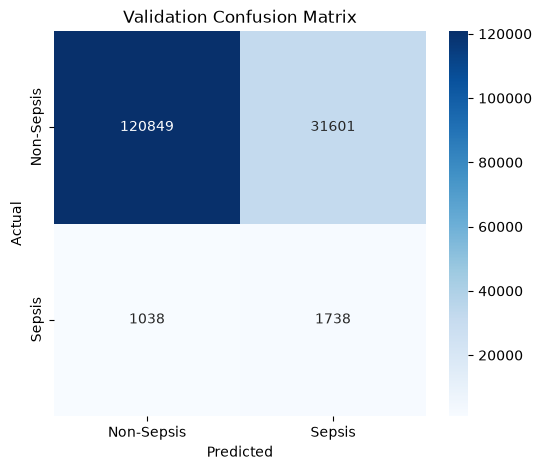

In [14]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Sepsis", "Sepsis"],
    yticklabels=["Non-Sepsis", "Sepsis"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()

In [15]:
print(
    classification_report(
        y_val,
        val_pred,
        target_names=["Non-Sepsis", "Sepsis"]
    )
)

              precision    recall  f1-score   support

  Non-Sepsis       0.99      0.79      0.88    152450
      Sepsis       0.05      0.63      0.10      2776

    accuracy                           0.79    155226
   macro avg       0.52      0.71      0.49    155226
weighted avg       0.97      0.79      0.87    155226



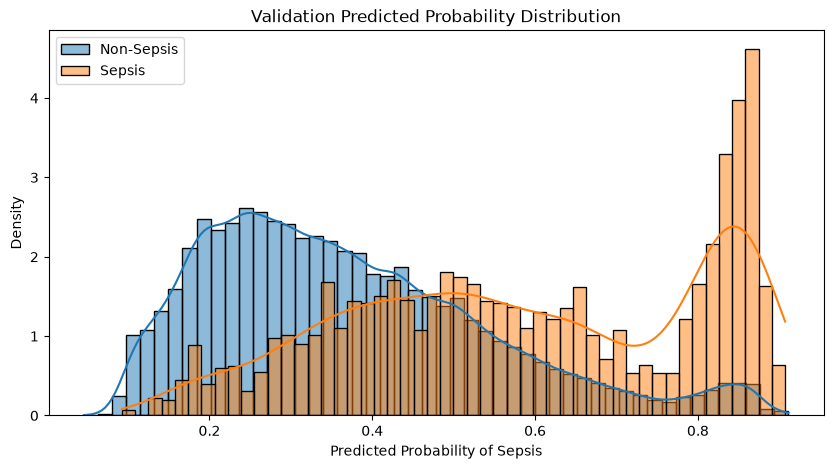

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    val_prob[y_val == 0],
    bins=50,
    stat="density",
    kde=True,
    label="Non-Sepsis",
    alpha=0.5
)

sns.histplot(
    val_prob[y_val == 1],
    bins=50,
    stat="density",
    kde=True,
    label="Sepsis",
    alpha=0.5
)

plt.xlabel("Predicted Probability of Sepsis")
plt.ylabel("Density")
plt.title("Validation Predicted Probability Distribution")
plt.legend()
plt.show()

In [17]:
print("Non-Sepsis probability percentiles:")
print(
    np.percentile(
        val_prob[y_val == 0],
        [50, 75, 90, 95, 99, 99.5, 99.9]
    )
)

print("\nSepsis probability percentiles:")
print(
    np.percentile(
        val_prob[y_val == 1],
        [10, 25, 50, 75, 90, 95, 99]
    )
)

Non-Sepsis probability percentiles:
[0.33794649 0.47074439 0.60763638 0.7147495  0.85711825 0.86784869
 0.890472  ]

Sepsis probability percentiles:
[0.3027792  0.4182711  0.58277509 0.81380107 0.86190921 0.8724981
 0.89847332]


In [18]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    val_pred_threshold = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            val_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            val_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            val_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.017987,0.998919,0.035337
1,0.15,0.018949,0.992435,0.037188
2,0.20,0.020676,0.965778,0.040485
3,0.25,0.023574,0.940922,0.045996
4,0.30,0.027269,0.901657,0.052938
5,0.35,0.031533,0.845101,0.060798
6,0.40,0.036722,0.777017,0.070129
7,0.45,0.043138,0.698487,0.081257
8,0.50,0.052131,0.626081,0.096248
9,0.55,0.063059,0.546110,0.113063


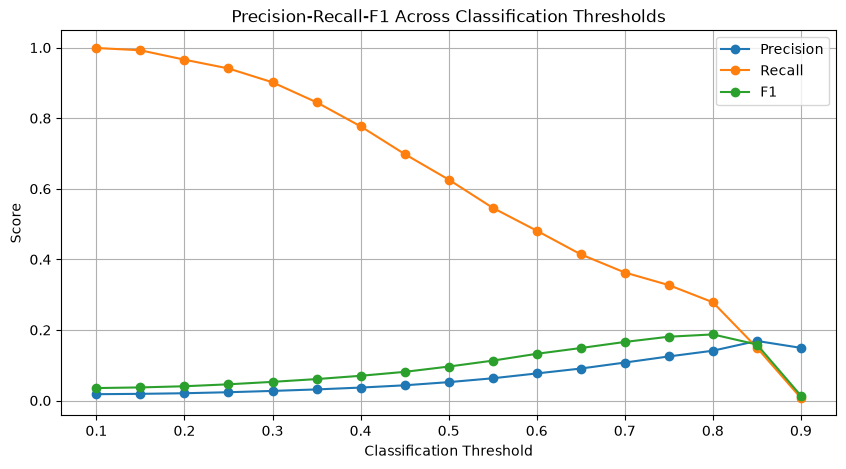

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 Across Classification Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_f1_row)

Threshold    0.800000
Precision    0.141187
Recall       0.278458
F1           0.187371
Name: 14, dtype: float64


In [21]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=final_features
).sort_values(ascending=False)

print(feature_importance)

ICULOS                        0.307865
Respiratory                   0.134946
Hour                          0.107581
ICU_Unit                      0.079999
HospAdmTime                   0.077891
Renal_Metabolic               0.066904
Gender                        0.062616
Inflammatory_Hematological    0.061798
Hepatic_Coagulation           0.053556
Hemodynamic                   0.046843
dtype: float32


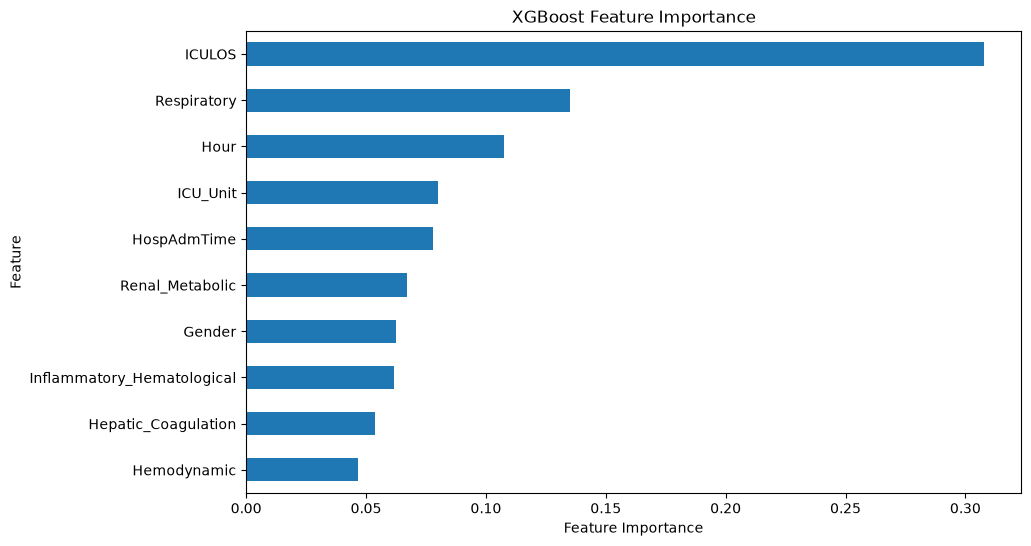

In [22]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()

In [23]:
clinical_model_features = [
    "Hemodynamic",
    "Respiratory",
    "Renal_Metabolic",
    "Inflammatory_Hematological",
    "Hepatic_Coagulation",
    "Gender",
    "ICU_Unit"
]

X_train_clinical = X_train[clinical_model_features].copy()
X_val_clinical = X_val[clinical_model_features].copy()

clinical_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

clinical_model.fit(
    X_train_clinical,
    y_train,
    eval_set=[(X_val_clinical, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.03807
[50]	validation_0-aucpr:0.04316
[100]	validation_0-aucpr:0.04496
[150]	validation_0-aucpr:0.04375
[200]	validation_0-aucpr:0.04344
[250]	validation_0-aucpr:0.04278
[299]	validation_0-aucpr:0.04215


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
clinical_results = clinical_model.evals_result()

clinical_val_aucpr = clinical_results["validation_0"]["aucpr"]

clinical_best_iteration = np.argmax(clinical_val_aucpr)
clinical_best_aucpr = clinical_val_aucpr[clinical_best_iteration]

print("Best iteration:", clinical_best_iteration)
print("Best validation PR-AUC:", clinical_best_aucpr)

Best iteration: 94
Best validation PR-AUC: 0.04508034432876741


In [25]:
tuned_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [26]:
tuned_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.07649
[50]	validation_0-aucpr:0.08598
[100]	validation_0-aucpr:0.08657
[150]	validation_0-aucpr:0.08724
[200]	validation_0-aucpr:0.08758
[250]	validation_0-aucpr:0.08730
[299]	validation_0-aucpr:0.08603


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
tuned_results = tuned_model.evals_result()

tuned_val_aucpr = tuned_results["validation_0"]["aucpr"]

tuned_best_iteration = np.argmax(tuned_val_aucpr)
tuned_best_aucpr = tuned_val_aucpr[tuned_best_iteration]

print("Best iteration:", tuned_best_iteration)
print("Best validation PR-AUC:", tuned_best_aucpr)

Best iteration: 220
Best validation PR-AUC: 0.08827952724018548


In [28]:
scale_pos_weight = 55.41

In [29]:
unweighted_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

unweighted_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.07898
[50]	validation_0-aucpr:0.08544
[100]	validation_0-aucpr:0.08384
[150]	validation_0-aucpr:0.08386
[200]	validation_0-aucpr:0.08285
[250]	validation_0-aucpr:0.08370
[299]	validation_0-aucpr:0.08280


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
unweighted_results = unweighted_model.evals_result()

unweighted_val_aucpr = unweighted_results["validation_0"]["aucpr"]

unweighted_best_iteration = np.argmax(unweighted_val_aucpr)
unweighted_best_aucpr = unweighted_val_aucpr[
    unweighted_best_iteration
]

print("Best iteration:", unweighted_best_iteration)
print("Best validation PR-AUC:", unweighted_best_aucpr)

Best iteration: 32
Best validation PR-AUC: 0.08644780978165191


In [31]:
regularized_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

regularized_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.07911
[50]	validation_0-aucpr:0.09027
[100]	validation_0-aucpr:0.08894
[150]	validation_0-aucpr:0.08659
[200]	validation_0-aucpr:0.08613
[250]	validation_0-aucpr:0.08456
[299]	validation_0-aucpr:0.08279


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
regularized_results = regularized_model.evals_result()

regularized_val_aucpr = (
    regularized_results["validation_0"]["aucpr"]
)

regularized_best_iteration = np.argmax(
    regularized_val_aucpr
)

regularized_best_aucpr = (
    regularized_val_aucpr[regularized_best_iteration]
)

print("Best iteration:", regularized_best_iteration)
print("Best validation PR-AUC:", regularized_best_aucpr)

Best iteration: 84
Best validation PR-AUC: 0.09062092805927684


In [33]:
final_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.07833
[50]	validation_0-aucpr:0.09113
[100]	validation_0-aucpr:0.08706
[150]	validation_0-aucpr:0.08684
[200]	validation_0-aucpr:0.08506
[250]	validation_0-aucpr:0.08441
[299]	validation_0-aucpr:0.08207


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
final_results = final_model.evals_result()

final_val_aucpr = final_results["validation_0"]["aucpr"]

final_best_iteration = np.argmax(final_val_aucpr)
final_best_aucpr = final_val_aucpr[final_best_iteration]

print("Best iteration:", final_best_iteration)
print("Best validation PR-AUC:", final_best_aucpr)

Best iteration: 47
Best validation PR-AUC: 0.09135831077031747


In [35]:
test_prob = final_model.predict_proba(X_test)[:, 1]

print("Test probability shape:", test_prob.shape)
print("Minimum probability:", test_prob.min())
print("Maximum probability:", test_prob.max())

Test probability shape: (309993,)
Minimum probability: 0.0007610814
Maximum probability: 0.9619644


In [36]:
test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

Test PR-AUC: 0.08809156136298536
Test ROC-AUC: 0.7862541082126292


In [37]:
final_threshold = 0.80

test_pred = (
    test_prob >= final_threshold
).astype(int)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)
print("Test Accuracy:", test_accuracy)

Test Precision: 0.13864365971107545
Test Recall: 0.2353542234332425
Test F1: 0.1744949494949495
Test Accuracy: 0.9578184023510208


In [38]:
cm = confusion_matrix(y_test, test_pred)

tn, fp, fn, tp = cm.ravel()

test_specificity = tn / (tn + fp)

print("Test Specificity:", test_specificity)

Test Specificity: 0.971767816099513


In [39]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Non-Sepsis       0.99      0.97      0.98    304121
      Sepsis       0.14      0.24      0.17      5872

    accuracy                           0.96    309993
   macro avg       0.56      0.60      0.58    309993
weighted avg       0.97      0.96      0.96    309993



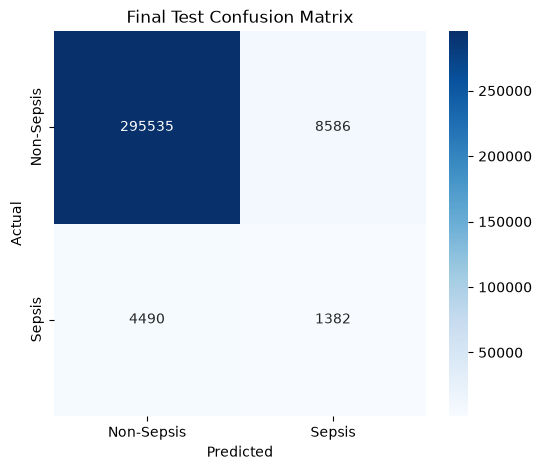

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Sepsis", "Sepsis"],
    yticklabels=["Non-Sepsis", "Sepsis"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Test Confusion Matrix")
plt.show()

___
___
# Summary

The final XGBoost model demonstrated stable ranking performance on the unseen test set (ROC-AUC = 0.7863; PR-AUC = 0.0881). However, classification performance for the minority sepsis class remained limited at the selected threshold, with precision of 0.14, recall of 0.24, and F1-score of 0.17. In contrast, non-sepsis classification achieved substantially higher performance. This indicates that severe class imbalance and substantial overlap between the predicted risk distributions remain important limitations of the current model.
___

In [41]:
feature_importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,ICULOS,0.307865
1,Respiratory,0.134946
5,Hour,0.107581
9,ICU_Unit,0.079999
7,HospAdmTime,0.077891
2,Renal_Metabolic,0.066904
8,Gender,0.062616
3,Inflammatory_Hematological,0.061798
4,Hepatic_Coagulation,0.053556
0,Hemodynamic,0.046843


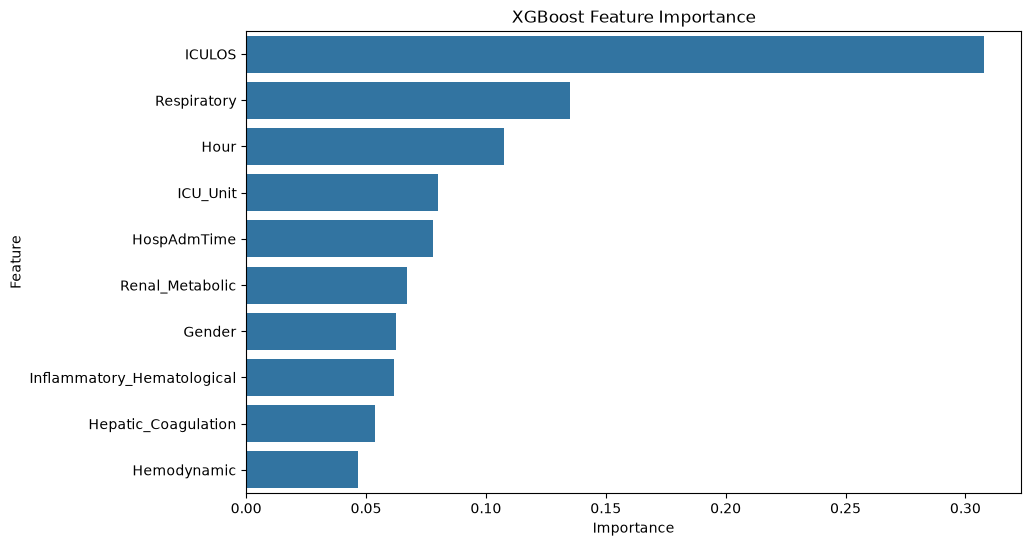

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

___
- This denotes that the model is being highly dependent on "ICULOS" than other clinical features or other features.
___

In [43]:
from sklearn.inspection import permutation_importance

In [44]:
sample_size = 20000

X_val_sample = X_val.sample(
    n=sample_size,
    random_state=42
)

y_val_sample = y_val.loc[X_val_sample.index]

In [45]:
perm_result = permutation_importance(
    model,
    X_val_sample,
    y_val_sample,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [46]:
permutation_importance_df = pd.DataFrame({
    "Feature": X_val_sample.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    "Importance_Mean",
    ascending=False
)

permutation_importance_df

,Feature,Importance_Mean,Importance_STD
6,ICULOS,0.045595,0.004281
5,Hour,0.025449,0.004329
1,Respiratory,0.020561,0.003247
2,Renal_Metabolic,0.015768,0.003617
3,Inflammatory_Hematological,0.013097,0.003230
4,Hepatic_Coagulation,0.004473,0.006042
8,Gender,0.002890,0.001642
7,HospAdmTime,0.001496,0.001882
0,Hemodynamic,0.001227,0.001779
9,ICU_Unit,-0.000631,0.003792


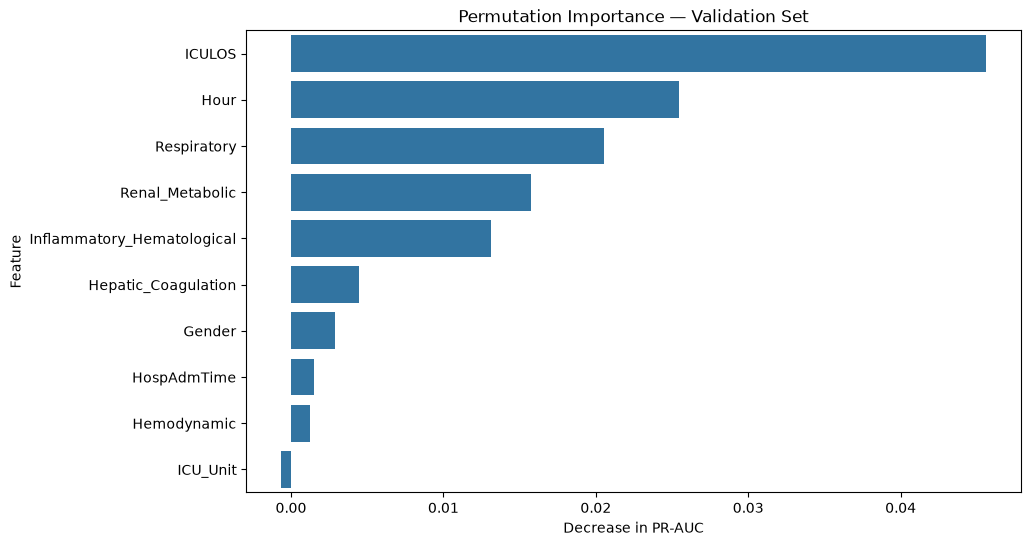

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=permutation_importance_df,
    x="Importance_Mean",
    y="Feature"
)

plt.title("Permutation Importance — Validation Set")
plt.xlabel("Decrease in PR-AUC")
plt.ylabel("Feature")
plt.show()

In [48]:
importance_comparison = feature_importance[
    ["Feature", "Importance"]
].merge(
    permutation_importance_df[
        ["Feature", "Importance_Mean"]
    ],
    on="Feature"
)

importance_comparison

,Feature,Importance,Importance_Mean
0,ICULOS,0.307865,0.045595
1,Respiratory,0.134946,0.020561
2,Hour,0.107581,0.025449
3,ICU_Unit,0.079999,-0.000631
4,HospAdmTime,0.077891,0.001496
5,Renal_Metabolic,0.066904,0.015768
6,Gender,0.062616,0.002890
7,Inflammatory_Hematological,0.061798,0.013097
8,Hepatic_Coagulation,0.053556,0.004473
9,Hemodynamic,0.046843,0.001227


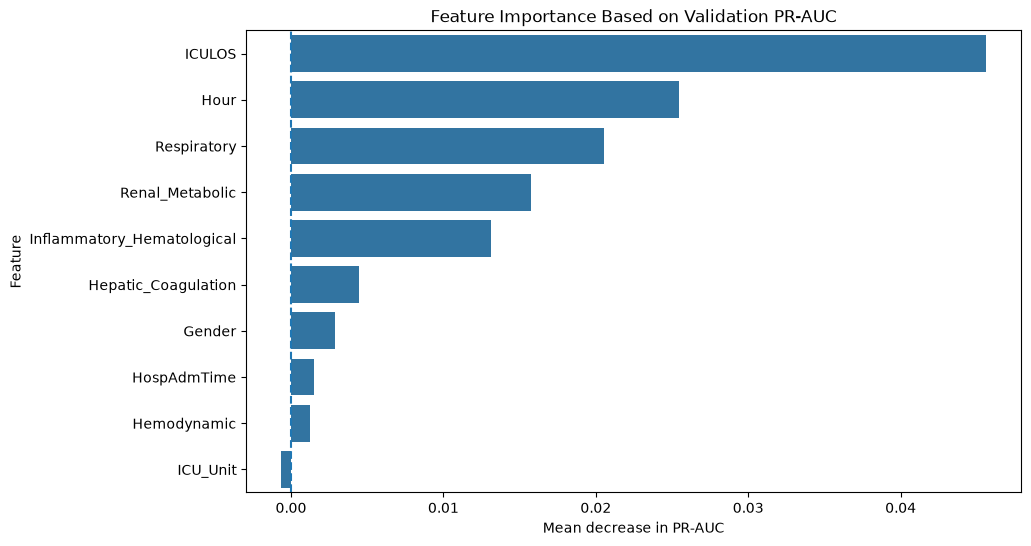

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=permutation_importance_df,
    x="Importance_Mean",
    y="Feature"
)

plt.axvline(0, linestyle="--")

plt.title("Feature Importance Based on Validation PR-AUC")
plt.xlabel("Mean decrease in PR-AUC")
plt.ylabel("Feature")

plt.show()

In [50]:
import shap

In [51]:
shap_sample_size = 5000

X_shap = X_val.sample(
    n=shap_sample_size,
    random_state=42
)

y_shap = y_val.loc[X_shap.index]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 10)


In [52]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

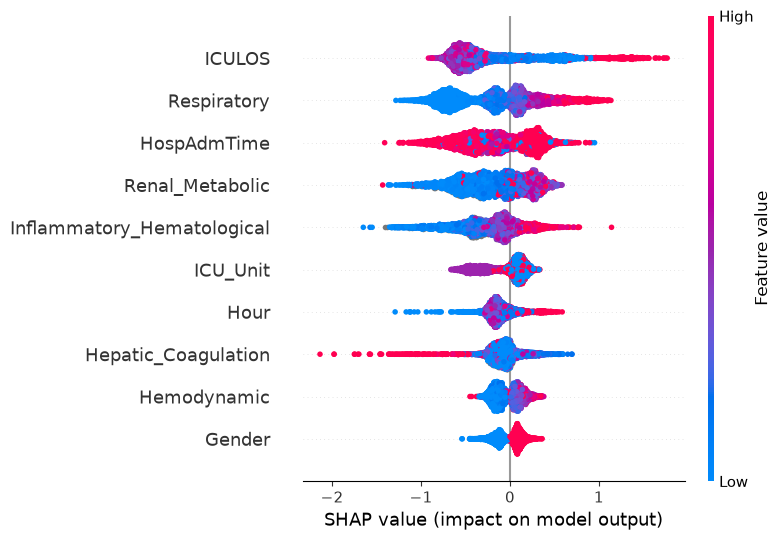

In [53]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns
)

## Findings

- ICULOS is the dominant feature across XGBoost importance, permutation importance, and SHAP.
- Hour is also an important temporal feature.
- Respiratory is the strongest clinical domain according to the permutation/SHAP analyses.
- Renal_Metabolic and Inflammatory_Hematological provide meaningful predictive information.
- ICU_Unit and HospAdmTime have relatively small permutation effects despite higher built-in XGBoost importance.
- SHAP shows that feature effects are not necessarily one-directional.
- The model's predictions are strongly influenced by temporal context, not only clinical domain scores.

In [54]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/xgboost_sepsis_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
